In [5]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

print("Library berhasil di-import!")

Library berhasil di-import!


In [6]:
# Bagian A1: Informasi Universe
print("=== INFORMASI UNIVERSE VARIABLE ===")
print("1. Pengalaman Kerja (Input): 0 - 25 Tahun | Ketelitian: Bebas | Jumlah Linguistik: 2 (Sedikit, Banyak)")
print("2. Nilai Ujian (Input)     : 0 - 10       | Ketelitian: 0.1   | Jumlah Linguistik: 3 (Rendah, Sedang, Tinggi)")
print("3. Gaji Pegawai (Output)   : Rp1.000.000 - Rp20.000.000 | Ketelitian: Bebas | Jumlah Linguistik: 2 (Kecil, Besar)")

=== INFORMASI UNIVERSE VARIABLE ===
1. Pengalaman Kerja (Input): 0 - 25 Tahun | Ketelitian: Bebas | Jumlah Linguistik: 2 (Sedikit, Banyak)
2. Nilai Ujian (Input)     : 0 - 10       | Ketelitian: 0.1   | Jumlah Linguistik: 3 (Rendah, Sedang, Tinggi)
3. Gaji Pegawai (Output)   : Rp1.000.000 - Rp20.000.000 | Ketelitian: Bebas | Jumlah Linguistik: 2 (Kecil, Besar)


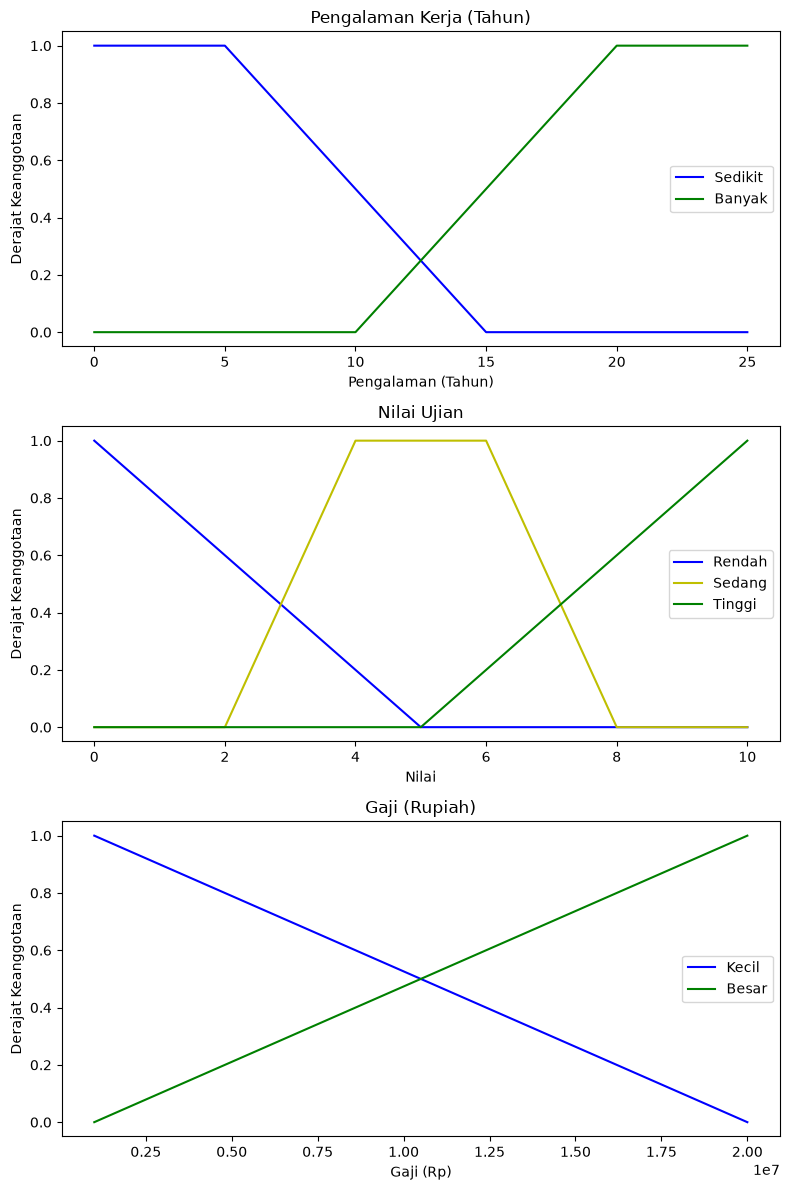

In [7]:
# Sumbu X (Universe)
pengalaman_x = np.arange(0, 25.1, 0.1)
nilai_x = np.arange(0, 10.1, 0.1)
gaji_x = np.arange(1000000, 20000001, 10000)

# 1. Pengalaman Kerja (Sedikit: trapesium turun 5-15, Banyak: trapesium naik 10-20)
pengalaman_sedikit = fuzz.trapmf(pengalaman_x, [0, 0, 5, 15])
pengalaman_banyak = fuzz.trapmf(pengalaman_x, [10, 20, 25, 25])

# 2. Nilai Ujian (Rendah: turun 0-5, Sedang: segitiga/trapesium 2-4-6-8, Tinggi: naik 5-10)
nilai_rendah = fuzz.trimf(nilai_x, [0, 0, 5])
nilai_sedang = fuzz.trapmf(nilai_x, [2, 4, 6, 8])
nilai_tinggi = fuzz.trimf(nilai_x, [5, 10, 10])

# 3. Gaji (Kecil: linear turun 1jt-20jt, Besar: linear naik 1jt-20jt)
gaji_kecil = fuzz.trimf(gaji_x, [1000000, 1000000, 20000000])
gaji_besar = fuzz.trimf(gaji_x, [1000000, 20000000, 20000000])

# Plotting Grafik Fungsi Keanggotaan
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, figsize=(8, 12))

# Grafik Pengalaman
ax0.plot(pengalaman_x, pengalaman_sedikit, 'b', linewidth=1.5, label='Sedikit')
ax0.plot(pengalaman_x, pengalaman_banyak, 'g', linewidth=1.5, label='Banyak')
ax0.set_title('Pengalaman Kerja (Tahun)')
ax0.set_xlabel('Pengalaman (Tahun)')
ax0.set_ylabel('Derajat Keanggotaan')
ax0.legend()

# Grafik Nilai Ujian
ax1.plot(nilai_x, nilai_rendah, 'b', linewidth=1.5, label='Rendah')
ax1.plot(nilai_x, nilai_sedang, 'y', linewidth=1.5, label='Sedang')
ax1.plot(nilai_x, nilai_tinggi, 'g', linewidth=1.5, label='Tinggi')
ax1.set_title('Nilai Ujian')
ax1.set_xlabel('Nilai')
ax1.set_ylabel('Derajat Keanggotaan')
ax1.legend()

# Grafik Gaji
ax2.plot(gaji_x, gaji_kecil, 'b', linewidth=1.5, label='Kecil')
ax2.plot(gaji_x, gaji_besar, 'g', linewidth=1.5, label='Besar')
ax2.set_title('Gaji (Rupiah)')
ax2.set_xlabel('Gaji (Rp)')
ax2.set_ylabel('Derajat Keanggotaan')
ax2.legend()

plt.tight_layout()
plt.show()

In [8]:
def input_validasi():
    while True:
        try:
            # Input Pengalaman
            exp_str = input("Masukkan Pengalaman Kerja (0 - 25 tahun): ").strip()
            if not exp_str:
                print("Error: Input tidak boleh kosong!\n")
                continue
            pengalaman_in = float(exp_str)
            if not (0 <= pengalaman_in <= 25):
                print("Peringatan: Pengalaman kerja harus dalam rentang 0 - 25 tahun!\n")
                continue

            # Input Nilai Ujian
            nilai_str = input("Masukkan Nilai Ujian (0 - 10, ketelitian 0.1): ").strip()
            if not nilai_str:
                print("Error: Input tidak boleh kosong!\n")
                continue
            nilai_in = float(nilai_str)
            if not (0 <= nilai_in <= 10):
                print("Peringatan: Nilai ujian harus dalam rentang 0 - 10!\n")
                continue

            # Pembulatan ketelitian 0.1
            nilai_in_rounded = round(nilai_in, 1)
            if abs(nilai_in - nilai_in_rounded) > 1e-5:
                print(f"Catatan: Nilai ujian {nilai_in} dibulatkan ke ketelitian 0.1 menjadi {nilai_in_rounded}.")
            nilai_in = nilai_in_rounded

            return pengalaman_in, nilai_in

        except ValueError:
            print("Error: Masukkan angka/desimal yang valid!\n")

# Jalankan Input Interaktif
pengalaman_input, nilai_input = input_validasi()

# --- A6. Hitung Derajat Keanggotaan ---
mu_peng_sedikit = fuzz.interp_membership(pengalaman_x, pengalaman_sedikit, pengalaman_input)
mu_peng_banyak = fuzz.interp_membership(pengalaman_x, pengalaman_banyak, pengalaman_input)

mu_nilai_rendah = fuzz.interp_membership(nilai_x, nilai_rendah, nilai_input)
mu_nilai_sedang = fuzz.interp_membership(nilai_x, nilai_sedang, nilai_input)
mu_nilai_tinggi = fuzz.interp_membership(nilai_x, nilai_tinggi, nilai_input)

print("\n" + "="*45)
print("HASIL DERAJAT KEANGGOTAAN (FUZZIFIKASI)")
print("="*45)
print(f"Pengalaman ({pengalaman_input} th) -> Sedikit: {mu_peng_sedikit:.2f} | Banyak: {mu_peng_banyak:.2f}")
print(f"Nilai Ujian ({nilai_input})    -> Rendah : {mu_nilai_rendah:.2f} | Sedang: {mu_nilai_sedang:.2f} | Tinggi: {mu_nilai_tinggi:.2f}")

# --- A7. Evaluasi 6 Rule Tsukamoto (Alpha & Z) ---
# Inversi Rumus Gaji Tsukamoto:
# Gaji Kecil: mu = (20jt - z) / 19jt  => z = 20jt - (mu * 19jt)
# Gaji Besar: mu = (z - 1jt) / 19jt   => z = 1jt + (mu * 19jt)

rules = [
    {"no": 1, "exp": "Sedikit", "mu_exp": mu_peng_sedikit, "nilai": "Rendah", "mu_nilai": mu_nilai_rendah, "out": "Kecil"},
    {"no": 2, "exp": "Sedikit", "mu_exp": mu_peng_sedikit, "nilai": "Sedang", "mu_nilai": mu_nilai_sedang, "out": "Kecil"},
    {"no": 3, "exp": "Sedikit", "mu_exp": mu_peng_sedikit, "nilai": "Tinggi", "mu_nilai": mu_nilai_tinggi, "out": "Kecil"},
    {"no": 4, "exp": "Banyak",  "mu_exp": mu_peng_banyak,  "nilai": "Rendah", "mu_nilai": mu_nilai_rendah, "out": "Kecil"},
    {"no": 5, "exp": "Banyak",  "mu_exp": mu_peng_banyak,  "nilai": "Sedang", "mu_nilai": mu_nilai_sedang, "out": "Besar"},
    {"no": 6, "exp": "Banyak",  "mu_exp": mu_peng_banyak,  "nilai": "Tinggi", "mu_nilai": mu_nilai_tinggi, "out": "Besar"},
]

alpha_list = []
z_list = []

print("\n" + "="*70)
print(f"{'RULE':<6} | {'KONDISI (IF)':<35} | {'THEN GAJI':<10} | {'ALPHA':<6} | {'Z (Rp)':<12}")
print("="*70)

for r in rules:
    alpha = min(r["mu_exp"], r["mu_nilai"])
    
    # Hitung Z berdasarkan inversi fungsi
    if r["out"] == "Kecil":
        z = 20000000 - (alpha * 19000000)
    else: # Besar
        z = 1000000 + (alpha * 19000000) # (1jt + alpha * 19jt)
        
    alpha_list.append(alpha)
    z_list.append(z)
    
    cond = f"Exp {r['exp']} AND Nilai {r['nilai']}"
    print(f"R{r['no']:<5} | IF {cond:<32} | {r['out']:<10} | {alpha:<6.2f} | Rp{z:11,.0f}")

# --- A8. Defuzzifikasi Tsukamoto (Rata-rata Terbobot) ---
sum_alpha_z = sum(a * z for a, z in zip(alpha_list, z_list))
sum_alpha = sum(alpha_list)

print("="*70)
if sum_alpha > 0:
    gaji_akhir = sum_alpha_z / sum_alpha
    print(f"\nHASIL DEFUZZIFIKASI TSUKAMOTO (Z AKHIR):")
    print(f"Gaji Pegawai Baru = Rp {gaji_akhir:,.2f}")
else:
    print("\nTidak ada rule yang aktif (Alpha total = 0).")


HASIL DERAJAT KEANGGOTAAN (FUZZIFIKASI)
Pengalaman (4.0 th) -> Sedikit: 1.00 | Banyak: 0.00
Nilai Ujian (6.7)    -> Rendah : 0.00 | Sedang: 0.65 | Tinggi: 0.34

RULE   | KONDISI (IF)                        | THEN GAJI  | ALPHA  | Z (Rp)      
R1     | IF Exp Sedikit AND Nilai Rendah     | Kecil      | 0.00   | Rp 20,000,000
R2     | IF Exp Sedikit AND Nilai Sedang     | Kecil      | 0.65   | Rp  7,650,000
R3     | IF Exp Sedikit AND Nilai Tinggi     | Kecil      | 0.34   | Rp 13,540,000
R4     | IF Exp Banyak AND Nilai Rendah      | Kecil      | 0.00   | Rp 20,000,000
R5     | IF Exp Banyak AND Nilai Sedang      | Besar      | 0.00   | Rp  1,000,000
R6     | IF Exp Banyak AND Nilai Tinggi      | Besar      | 0.00   | Rp  1,000,000

HASIL DEFUZZIFIKASI TSUKAMOTO (Z AKHIR):
Gaji Pegawai Baru = Rp 9,672,828.28
